Given:
arr = np.arange(1, 17).reshape(4, 4)

Tasks:
Extract the secondary diagonal (top-right to bottom-left)
Reverse each row of the matrix (no loops)
Select elements greater than the mean and reshape them into a column vector
Swap the first and last rows using indexing only

In [1]:
import numpy as np

In [2]:
arr=np.arange(1,17)
arr_reshape=np.reshape(arr, (4,4))
print(arr_reshape)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]


In [3]:
x=np.diag(arr_reshape[::-1])
print(x[::-1])

[ 4  7 10 13]


In [4]:
arr_reshape[::,::-1]

array([[ 4,  3,  2,  1],
       [ 8,  7,  6,  5],
       [12, 11, 10,  9],
       [16, 15, 14, 13]])

In [5]:
greater_than_mean=arr_reshape[arr_reshape > np.mean(arr_reshape)]
#greater_than_mean
col_vector=np.reshape(greater_than_mean, (8,1))
print(col_vector)

[[ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]]


In [6]:
arr_reshape[[0,-1]]=arr_reshape[[-1,0]]
print(arr_reshape)

[[13 14 15 16]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [ 1  2  3  4]]


In [7]:
import pandas as pd

"Name": ["A", "B", "C", "D", "E", "F"], 
"Dept": ["CS", "IT", "CS", "IT", "CS", "IT"],
"Marks": [85, 40, 78, 90, 55, 30],
"Attendance": [90, 60, 75, 80, 65, 50]

Create a new column "Result" - Pass if Marks ≥ 50, else Fail
Create "Grade" column:
      ≥ 80 → A
     60–79 → B< 60 → C
Find average marks per department
Find top scorer in each department
Filter students:
     Passed AND Attendance > 70
Sort by:
     Dept (ascending), Marks (descending)

In [8]:
d={
    "Name":["A", "B", "C", "D", "E", "F"],
    "Dept":["CS", "IT", "CS", "IT", "CS", "IT"],
    "Marks":[85, 40, 78, 90, 55, 30],
    "Attendance":[90, 60, 75, 80, 65, 50]
}
df=pd.DataFrame(d,index=[1,2,3,4,5,6])
df

,Name,Dept,Marks,Attendance
1,A,CS,85,90
2,B,IT,40,60
3,C,CS,78,75
4,D,IT,90,80
5,E,CS,55,65
6,F,IT,30,50


In [9]:
df['Result']=df['Marks'].apply(lambda x: "Pass" if x>=50 else "Fail")
df

,Name,Dept,Marks,Attendance,Result
1,A,CS,85,90,Pass
2,B,IT,40,60,Fail
3,C,CS,78,75,Pass
4,D,IT,90,80,Pass
5,E,CS,55,65,Pass
6,F,IT,30,50,Fail


In [10]:
def grade(num):
    g=""
    if num>=80:
        g="A"
    elif num>=60 and num<80:
        g="B"
    else:
        g="C"
    return g
df['Grade']=df['Marks'].apply(grade)
df

,Name,Dept,Marks,Attendance,Result,Grade
1,A,CS,85,90,Pass,A
2,B,IT,40,60,Fail,C
3,C,CS,78,75,Pass,B
4,D,IT,90,80,Pass,A
5,E,CS,55,65,Pass,C
6,F,IT,30,50,Fail,C


In [11]:
x=df['Dept'].unique()
print(x)

['CS' 'IT']


In [12]:
x=df.sort_values(by='Dept', ascending=True)
x

,Name,Dept,Marks,Attendance,Result,Grade
1,A,CS,85,90,Pass,A
3,C,CS,78,75,Pass,B
5,E,CS,55,65,Pass,C
2,B,IT,40,60,Fail,C
4,D,IT,90,80,Pass,A
6,F,IT,30,50,Fail,C


In [13]:
y=df.sort_values(by='Marks', ascending=True)
y

,Name,Dept,Marks,Attendance,Result,Grade
6,F,IT,30,50,Fail,C
2,B,IT,40,60,Fail,C
5,E,CS,55,65,Pass,C
3,C,CS,78,75,Pass,B
1,A,CS,85,90,Pass,A
4,D,IT,90,80,Pass,A


In [14]:
df[(df['Result']=="Pass") & (df['Attendance']>70)]


,Name,Dept,Marks,Attendance,Result,Grade
1,A,CS,85,90,Pass,A
3,C,CS,78,75,Pass,B
4,D,IT,90,80,Pass,A


In [15]:
avg_marks=df.groupby('Dept')['Marks'].mean()
print(avg_marks)

Dept
CS    72.666667
IT    53.333333
Name: Marks, dtype: float64


In [16]:
top_scorer_per_dept=df.loc[df.groupby('Dept')['Marks'].idxmax(), ["Name","Dept","Marks"]]
top_scorer_per_dept.reset_index()

,index,Name,Dept,Marks
0,1,A,CS,85
1,4,D,IT,90


In [17]:
data={
    "Name":["Riya","Soham","Priya","Arjun","Neha"],
    "Stream":["Science","Commerce","Science","Arts","Commerce"],
    "Marks":[92,45,78,88,60],
    "Income":[200000, 300000, 400000, 150000, 300000],
    "Attendance":[88,55,70,92,65]
}
new=pd.DataFrame(data, index=[1,2,3,4,5])
new

,Name,Stream,Marks,Income,Attendance
1,Riya,Science,92,200000,88
2,Soham,Commerce,45,300000,55
3,Priya,Science,78,400000,70
4,Arjun,Arts,88,150000,92
5,Neha,Commerce,60,300000,65


In [18]:
def scholarship(t):
    if t['Marks'] >= 75 and t['Income']<500000:
        return "Yes"
    else:
        return "No"
#new['Scholarship']=new.apply(scholarship, axis=1)
new['Scholarship']=new.apply(lambda x: "Yes" if x['Marks']>=75 and x['Income']<500000
                            else "No", axis=1)
new

,Name,Stream,Marks,Income,Attendance,Scholarship
1,Riya,Science,92,200000,88,Yes
2,Soham,Commerce,45,300000,55,No
3,Priya,Science,78,400000,70,Yes
4,Arjun,Arts,88,150000,92,Yes
5,Neha,Commerce,60,300000,65,No


In [19]:
def merit(num):
    category=""
    if num>=80:
        category="Merit"
    elif num>=60 and num<80:
        category="Average"
    else:
        category="Below Average"
    return category
new['Category']=new['Marks'].apply(merit)
new

,Name,Stream,Marks,Income,Attendance,Scholarship,Category
1,Riya,Science,92,200000,88,Yes,Merit
2,Soham,Commerce,45,300000,55,No,Below Average
3,Priya,Science,78,400000,70,Yes,Average
4,Arjun,Arts,88,150000,92,Yes,Merit
5,Neha,Commerce,60,300000,65,No,Average


In [20]:
mean_marks=new.groupby('Stream')['Marks'].mean()
mean_marks

Stream
Arts        88.0
Commerce    52.5
Science     85.0
Name: Marks, dtype: float64

In [21]:
mean_attn=new.groupby('Stream')['Attendance'].mean()
mean_attn

Stream
Arts        92.0
Commerce    60.0
Science     79.0
Name: Attendance, dtype: float64

In [27]:
mean=new.groupby('Stream')[['Marks','Attendance']].mean()
mean

,Marks,Attendance
Stream,,
Arts,88.0,92.0
Commerce,52.5,60.0
Science,85.0,79.0


In [22]:
topper=new.loc[new.groupby('Stream')['Marks'].idxmax(), ["Name", "Stream","Marks"]]
topper.set_index("Stream")

,Name,Marks
Stream,,
Arts,Arjun,88
Commerce,Neha,60
Science,Riya,92


In [23]:
new[(new['Scholarship']=='Yes')&(new['Attendance']>70)]

,Name,Stream,Marks,Income,Attendance,Scholarship,Category
1,Riya,Science,92,200000,88,Yes,Merit
4,Arjun,Arts,88,150000,92,Yes,Merit


In [24]:
x=new.sort_values(by='Stream', ascending=True)
x

,Name,Stream,Marks,Income,Attendance,Scholarship,Category
4,Arjun,Arts,88,150000,92,Yes,Merit
2,Soham,Commerce,45,300000,55,No,Below Average
5,Neha,Commerce,60,300000,65,No,Average
1,Riya,Science,92,200000,88,Yes,Merit
3,Priya,Science,78,400000,70,Yes,Average


In [25]:
y=x.sort_values(by='Marks', ascending=False)
y

,Name,Stream,Marks,Income,Attendance,Scholarship,Category
1,Riya,Science,92,200000,88,Yes,Merit
4,Arjun,Arts,88,150000,92,Yes,Merit
3,Priya,Science,78,400000,70,Yes,Average
5,Neha,Commerce,60,300000,65,No,Average
2,Soham,Commerce,45,300000,55,No,Below Average


In [26]:
data = {
    "Salesperson": ["Amit", "Beena", "Chirag", "Divya", "Eshan", "Farida"],
    "Region": ["North", "South", "North", "East", "South", "East"],
    "Q1": [45000, 32000, 67000, 54000, 28000, 71000],
    "Q2": [52000, 41000, 59000, 48000, 37000, 68000],
    "Q3": [61000, 29000, 72000, 53000, 44000, 75000],
    "Q4": [58000, 35000, 80000, 49000, 31000, 82000]
}
df=pd.DataFrame(data, index=[1,2,3,4,5,6])
df

,Salesperson,Region,Q1,Q2,Q3,Q4
1,Amit,North,45000,52000,61000,58000
2,Beena,South,32000,41000,29000,35000
3,Chirag,North,67000,59000,72000,80000
4,Divya,East,54000,48000,53000,49000
5,Eshan,South,28000,37000,44000,31000
6,Farida,East,71000,68000,75000,82000


In [29]:
df['Annual Sales']=df.apply(lambda x:x['Q1']+x['Q2']+x['Q3']+x['Q4'], axis=1)
df

,Salesperson,Region,Q1,Q2,Q3,Q4,Annual Sales
1,Amit,North,45000,52000,61000,58000,216000
2,Beena,South,32000,41000,29000,35000,137000
3,Chirag,North,67000,59000,72000,80000,278000
4,Divya,East,54000,48000,53000,49000,204000
5,Eshan,South,28000,37000,44000,31000,140000
6,Farida,East,71000,68000,75000,82000,296000


In [32]:
def perf(rate):
    performance=""
    if rate>=250000:
        performance="Star"
    elif rate>=180000:
        performance="Good"
    else:
        performance="Needs Improvement"
    return performance
df['Performance']=df['Annual Sales'].apply(perf)
df

,Salesperson,Region,Q1,Q2,Q3,Q4,Annual Sales,Performance
1,Amit,North,45000,52000,61000,58000,216000,Good
2,Beena,South,32000,41000,29000,35000,137000,Needs Improvement
3,Chirag,North,67000,59000,72000,80000,278000,Star
4,Divya,East,54000,48000,53000,49000,204000,Good
5,Eshan,South,28000,37000,44000,31000,140000,Needs Improvement
6,Farida,East,71000,68000,75000,82000,296000,Star


In [37]:
region_total=df.groupby('Region')['Annual Sales'].sum()
region_total

Region
East     500000
North    494000
South    277000
Name: Annual Sales, dtype: int64

In [49]:
best_performing_quarter=df[['Q1','Q2','Q3','Q4']].apply(lambda x:x.max()).idxmax()
best_performing_quarter_value=df[['Q1','Q2','Q3','Q4']].apply(lambda x:x.max()).max()
best_performing_quarter, best_performing_quarter_value

('Q4', 82000)

In [52]:
filter_reg=df[(df['Region'].isin(['North', 'East'])) & (df['Performance']=="Good")]
filter_reg

,Salesperson,Region,Q1,Q2,Q3,Q4,Annual Sales,Performance
1,Amit,North,45000,52000,61000,58000,216000,Good
4,Divya,East,54000,48000,53000,49000,204000,Good


In [53]:
df['Growth']=df['Q4']-df['Q1']
df

,Salesperson,Region,Q1,Q2,Q3,Q4,Annual Sales,Performance,Growth
1,Amit,North,45000,52000,61000,58000,216000,Good,13000
2,Beena,South,32000,41000,29000,35000,137000,Needs Improvement,3000
3,Chirag,North,67000,59000,72000,80000,278000,Star,13000
4,Divya,East,54000,48000,53000,49000,204000,Good,-5000
5,Eshan,South,28000,37000,44000,31000,140000,Needs Improvement,3000
6,Farida,East,71000,68000,75000,82000,296000,Star,11000


In [54]:
sort=df.sort_values(by='Growth', ascending=False)
sort

,Salesperson,Region,Q1,Q2,Q3,Q4,Annual Sales,Performance,Growth
1,Amit,North,45000,52000,61000,58000,216000,Good,13000
3,Chirag,North,67000,59000,72000,80000,278000,Star,13000
6,Farida,East,71000,68000,75000,82000,296000,Star,11000
2,Beena,South,32000,41000,29000,35000,137000,Needs Improvement,3000
5,Eshan,South,28000,37000,44000,31000,140000,Needs Improvement,3000
4,Divya,East,54000,48000,53000,49000,204000,Good,-5000


In [55]:
import matplotlib.pyplot as plt

In [61]:
data = {
    "OrderID": range(1, 11),
    "Category": ["Electronics","Clothing","Electronics","Books","Clothing",
                  "Books","Electronics","Clothing","Books","Electronics"],
    "Price": [15000, 1200, 8000, 450, 2200, 380, 25000, 900, 520, 12000],
    "Quantity": [1, 3, 2, 5, 2, 4, 1, 3, 6, 2],
    "Rating": [4.5, 3.8, 4.2, 4.9, 3.5, 4.7, 4.8, 3.2, 4.6, 4.1]
}
x=pd.DataFrame(data)
df=x.set_index('OrderID')
df

,Category,Price,Quantity,Rating
OrderID,,,,
1,Electronics,15000,1,4.5
2,Clothing,1200,3,3.8
3,Electronics,8000,2,4.2
4,Books,450,5,4.9
5,Clothing,2200,2,3.5
6,Books,380,4,4.7
7,Electronics,25000,1,4.8
8,Clothing,900,3,3.2
9,Books,520,6,4.6


In [62]:
df['Total_Value']=df['Price']*df['Quantity']
df

,Category,Price,Quantity,Rating,Total_Value
OrderID,,,,,
1,Electronics,15000,1,4.5,15000
2,Clothing,1200,3,3.8,3600
3,Electronics,8000,2,4.2,16000
4,Books,450,5,4.9,2250
5,Clothing,2200,2,3.5,4400
6,Books,380,4,4.7,1520
7,Electronics,25000,1,4.8,25000
8,Clothing,900,3,3.2,2700
9,Books,520,6,4.6,3120


In [63]:
df['Discount']=df['Total_Value'].apply(lambda x:x*0.10 if x>10000 else x*0.05)
df

,Category,Price,Quantity,Rating,Total_Value,Discount
OrderID,,,,,,
1,Electronics,15000,1,4.5,15000,1500.0
2,Clothing,1200,3,3.8,3600,180.0
3,Electronics,8000,2,4.2,16000,1600.0
4,Books,450,5,4.9,2250,112.5
5,Clothing,2200,2,3.5,4400,220.0
6,Books,380,4,4.7,1520,76.0
7,Electronics,25000,1,4.8,25000,2500.0
8,Clothing,900,3,3.2,2700,135.0
9,Books,520,6,4.6,3120,156.0


In [64]:
df['Final_Value']=df['Total_Value']-df['Discount']
df

,Category,Price,Quantity,Rating,Total_Value,Discount,Final_Value
OrderID,,,,,,,
1,Electronics,15000,1,4.5,15000,1500.0,13500.0
2,Clothing,1200,3,3.8,3600,180.0,3420.0
3,Electronics,8000,2,4.2,16000,1600.0,14400.0
4,Books,450,5,4.9,2250,112.5,2137.5
5,Clothing,2200,2,3.5,4400,220.0,4180.0
6,Books,380,4,4.7,1520,76.0,1444.0
7,Electronics,25000,1,4.8,25000,2500.0,22500.0
8,Clothing,900,3,3.2,2700,135.0,2565.0
9,Books,520,6,4.6,3120,156.0,2964.0


In [67]:
tot_final=df.groupby('Category')['Final_Value'].sum()
tot_final

Category
Books           6545.5
Clothing       10165.0
Electronics    72000.0
Name: Final_Value, dtype: float64

In [70]:
avg_rating=df.groupby('Category')['Rating'].mean()
avg_rating

Category
Books          4.733333
Clothing       3.500000
Electronics    4.400000
Name: Rating, dtype: float64

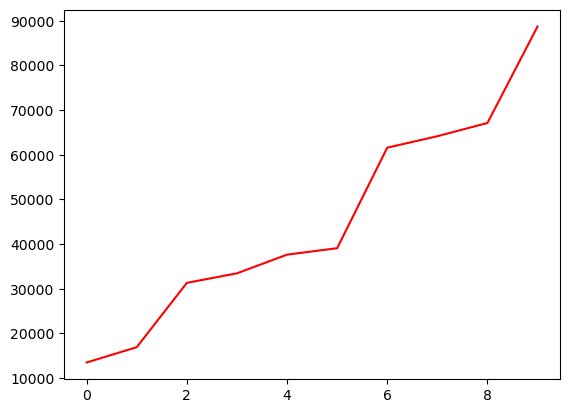

In [80]:
final_value=np.array(df['Final_Value'], dtype=int)
cumsum=final_value.cumsum(axis=0)
plt.plot(cumsum, linestyle='-',color='red')
plt.show()

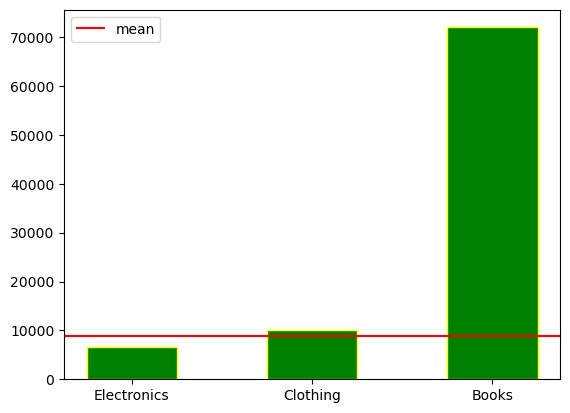

In [90]:
x=df['Category'].unique()
y=df.groupby('Category')['Final_Value'].sum()
mean=df['Final_Value'].mean()

plt.bar(x,y,width=0.5,color='green',edgecolor='yellow')
plt.axhline(mean,color='red',label="mean")
plt.legend()
plt.show()

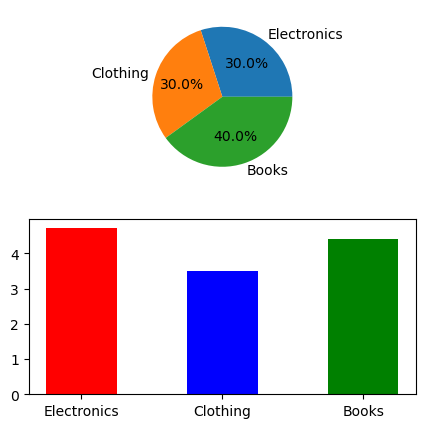

In [114]:
z=df.reset_index()
pie=z.groupby('Category')['OrderID'].count()
plt.figure(figsize=(5,5))
plt.subplot(2,1,1)
plt.pie(pie,labels=['Electronics','Clothing','Books'],autopct='%1.1f%%')


rate=df.groupby('Category')['Rating'].mean()
plt.subplot(2,1,2)
plt.bar(x, rate,color=['red','blue','green'],width=0.5)
plt.show()

In [115]:
data={
    "Employee":["A","B","C","D","E","F","G","H"],
    "Department":["HR","Tech","Tech","HR","Finance","Finance","Tech","HR"],
    "Salary":[45000,90000,85000,52000,70000,68000,95000,48000],
    "Experience":[2,7,5,3,6,4,8,1],
    "Rating":[3.2,4.8,4.5,3.5,4.1,3.9,4.9,3.0]
}
df=pd.DataFrame(data)
df

,Employee,Department,Salary,Experience,Rating
0,A,HR,45000,2,3.2
1,B,Tech,90000,7,4.8
2,C,Tech,85000,5,4.5
3,D,HR,52000,3,3.5
4,E,Finance,70000,6,4.1
5,F,Finance,68000,4,3.9
6,G,Tech,95000,8,4.9
7,H,HR,48000,1,3.0


In [116]:
def salband(sal):
    salary_band=""
    if sal<60000:
        salary_band="Junior"
    elif sal<85000 and sal>=60000:
        salary_band="Mid"
    else:
        salary_band="Senior"
    return salary_band
df['Salary_band']=df['Salary'].apply(salband)
df

,Employee,Department,Salary,Experience,Rating,Salary_band
0,A,HR,45000,2,3.2,Junior
1,B,Tech,90000,7,4.8,Senior
2,C,Tech,85000,5,4.5,Senior
3,D,HR,52000,3,3.5,Junior
4,E,Finance,70000,6,4.1,Mid
5,F,Finance,68000,4,3.9,Mid
6,G,Tech,95000,8,4.9,Senior
7,H,HR,48000,1,3.0,Junior


In [126]:
mean_sal_rating=df.groupby('Department')[['Salary','Rating']].mean()
mean_sal_rating

,Salary,Rating
Department,,
Finance,69000.000000,4.000000
HR,48333.333333,3.233333
Tech,90000.000000,4.733333


In [128]:
salary_arr=np.array(df['Salary'])
mean=np.mean(salary_arr)
median=np.median(salary_arr)
std=np.std(salary_arr)
print(f"Mean:{mean}, Median:{median}, Std:{std}")

Mean:69125.0, Median:69000.0, Std:18305.992871188384


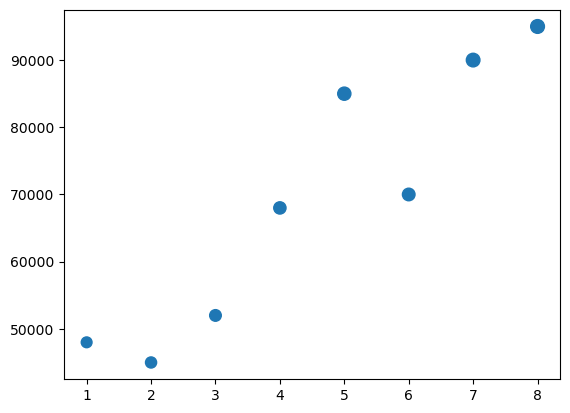

In [132]:
color=df.groupby('Department')
plt.scatter(df['Experience'],df['Salary'],s=df['Rating']*20)
plt.show()

In [133]:
data={
    "Name":["Riya","Soham","Priya","Arjun","Neha","Dev"],
    "Maths":[85,42,78,91,60,35],
    "Science":[90,55,70,88,45,72],
    "English":[76,68,82,79,55,61],
    "Attendance":[92,55,78,88,65,48],
}
df=pd.DataFrame(data)
df

,Name,Maths,Science,English,Attendance
0,Riya,85,90,76,92
1,Soham,42,55,68,55
2,Priya,78,70,82,78
3,Arjun,91,88,79,88
4,Neha,60,45,55,65
5,Dev,35,72,61,48


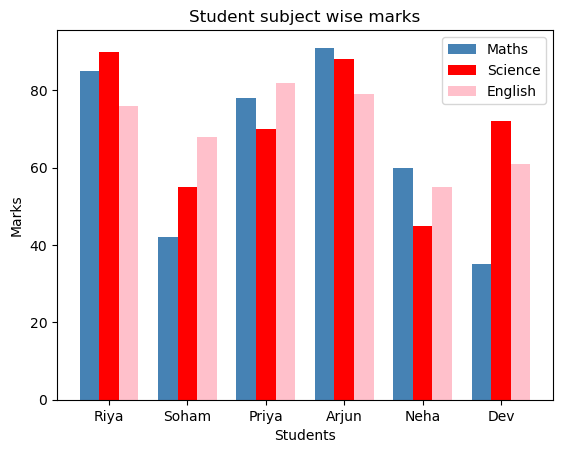

In [142]:
names=data['Name']
x=np.arange(len(names))
width=0.25
plt.bar(x-width,df["Maths"],width=width,label="Maths",color="steelblue")
plt.bar(x,df["Science"],width=width,label="Science",color="red")
plt.bar(x+width,df["English"],width=width,label="English",color="pink")

plt.xticks(x,df["Name"])
plt.xlabel("Students")
plt.ylabel("Marks")
plt.legend()
plt.title("Student subject wise marks")
plt.show()

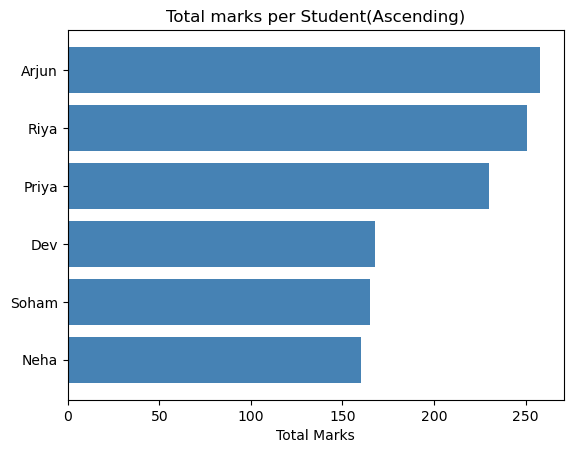

In [144]:
df['Total']=df['Maths']+df['Science']+df['English']
df=df.sort_values("Total")
plt.barh(df['Name'],df['Total'],color="steelblue")
plt.xlabel("Total Marks")
plt.title("Total marks per Student(Ascending)")
plt.show()

In [148]:
",".join(['A','B','C'])


'A,B,C'

In [149]:
data={
    "Name":["Riya","Soham","Priya","Arjun","Neha","Dev"],
    "Maths":[85,42,78,91,60,35],
    "Science":[90,55,70,88,45,72],
    "English":[76,68,82,79,55,61],
    "Attendance":[92,55,78,88,65,48],
}
df=pd.DataFrame(data)
df

,Name,Maths,Science,English,Attendance
0,Riya,85,90,76,92
1,Soham,42,55,68,55
2,Priya,78,70,82,78
3,Arjun,91,88,79,88
4,Neha,60,45,55,65
5,Dev,35,72,61,48


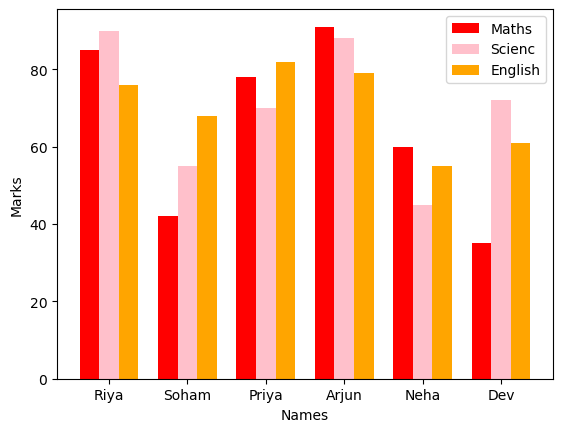

In [156]:
x=np.arange(len(df['Name']))
width=0.25
plt.bar(x-width, df['Maths'], width, label='Maths', color='red')
plt.bar(x, df['Science'], width, label='Scienc', color='pink')
plt.bar(x+width, df['English'], width, label='English', color='orange')
plt.legend()
plt.xticks(x,df['Name'])
plt.xlabel('Names')
plt.ylabel('Marks')
plt.show()

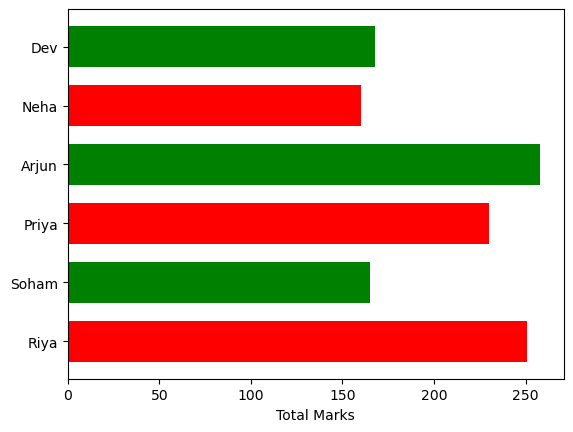

In [164]:
df['Total']=df['Maths']+df['Science']+df['English']
plt.barh(df['Name'],df['Total'], height=0.7, color=['Red','Green'])
plt.xlabel('Total Marks')
plt.show()

In [167]:
df['Average']=df['Total'].apply(lambda x: x/3)
df

,Name,Maths,Science,English,Attendance,Total,Average
0,Riya,85,90,76,92,251,83.666667
1,Soham,42,55,68,55,165,55.000000
2,Priya,78,70,82,78,230,76.666667
3,Arjun,91,88,79,88,258,86.000000
4,Neha,60,45,55,65,160,53.333333
5,Dev,35,72,61,48,168,56.000000


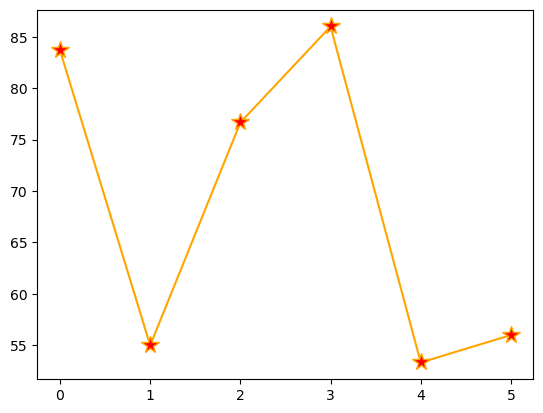

In [172]:
plt.plot(df['Average'], marker='*',mfc='red',markersize='13',linestyle='-',color='orange')
plt.show()

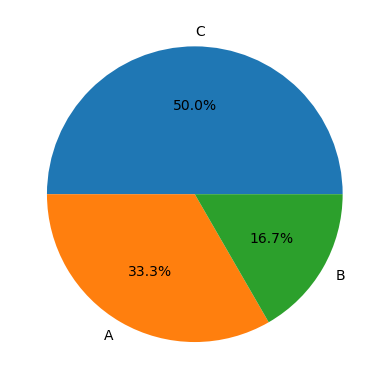

In [179]:
def grade(avg):
    g=""
    if avg>=80.0:
        g="A"
    elif avg>=60.0 and avg<80:
        g="B"
    elif avg>=40 and avg<60:
        g="C"
    else:
        g="F"
    return g

df['Grade']=df['Average'].apply(grade)
grade_counts=df['Grade'].value_counts()
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%')
plt.show()

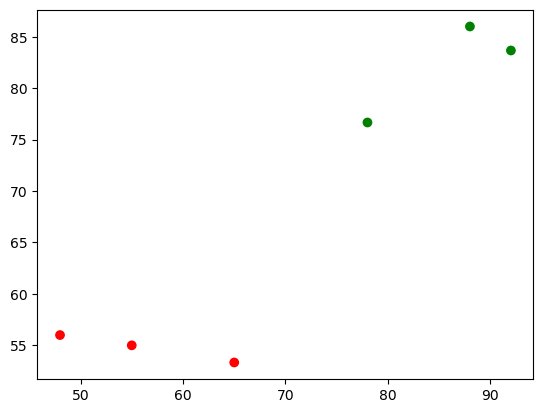

In [180]:
plt.scatter(df['Attendance'],df['Average'],c=['Red' if v<60 else 'Green' for v in df['Average']])
plt.show()

In [181]:
l=[" iphone-14 Pro ", "SAMSUNG galaxy S23", "oneplus_11", "Pixel--7 Pro", " xiaomi 13 "]
ser=pd.Series(l)
ser

0        iphone-14 Pro 
1    SAMSUNG galaxy S23
2            oneplus_11
3          Pixel--7 Pro
4            xiaomi 13 
dtype: object

In [183]:
def clean(name):
    name=name.replace('-', ' ')
    name=name.replace('_',' ')
    name=name.strip()
    res=''
    for i in range(len(name)):
        if name[i-1].isspace() and name[i].isspace():
            continue
        res+=name[i]
    name=res.title()
    return name
clean_name=ser.apply(clean)
clean_name

0         Iphone 14 Pro
1    Samsung Galaxy S23
2            Oneplus 11
3           Pixel 7 Pro
4             Xiaomi 13
dtype: object

In [187]:
def strength(password):
    
    nu=0
    nl=0
    nd=0
    nsp=0
    prev=""
    c=1
    if len(password)>=8:
        for i in range(len(password)):        
            if password[i].isupper():
                nu+=1
            elif password[i].islower():
                nl+=1
            elif password[i].isdigit():
                nd+=1
            elif password[i] in '!@#$%^&*':
                nsp+=1
            if password[i]==prev:
                c+=1
                if c>3:
                    return 'Weak'
            else:
                c=1     
            prev=password[i]
        if nu>=1 and nl>=1 and nd>=1 and nsp>=1:
            return 'Strong'
        else:
            return 'Moderate'
    
    return 'Weak'
ser=pd.Series(["Admin123!"])
password=ser.apply(strength)
password

0    Strong
dtype: object